<a href="https://colab.research.google.com/github/webpug/geospatial/blob/main/standout_systems_labelling_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 You Are Hand-Labelling Data Google Already Described for Free

### A 25-minute playground · Standout Systems
by **Teodora Szasz, PhD** · [teodoracoach.substack.com](https://teodoracoach.substack.com/) · [teodora.coach](https://teodora.coach/)

---

Google spent an enormous amount of money teaching an AI model to look at the entire planet.

Then they did something surprising. They **kept the model** and **gave away what it learned**, for free, to anyone.

You are about to use it. No coding background needed beyond running cells. No GPU. No credit card. No downloads.

---

## What you will actually get to do

| Step | You will play with | Time |
|:--|:--|:--|
| 1 | Turning the lights on | 3 min |
| 2 | 🎨 Painting the Earth in AI's own colours | 2 min |
| 3 | 🌐 Finding "twin" places across the world | 3 min |
| 4 | 🔦 Clicking one spot and lighting up everywhere similar | 4 min |
| 5 | 🗺️ Watching the AI sort places it was never taught about | 4 min |
| 6 | 📈 **The big one.** Proving this saves real money | 6 min |
| 7 | 🕵️ Spotting what changed on Earth between 2018 and 2024 | 3 min |

**By the end you will be able to say, with a chart to back it up:** *"Using a pre-trained AI representation instead of raw data cut the amount of hand-labelling we need by X%."*

That sentence is worth a lot in a meeting.

---

## Six words you will need

| Word | What it actually means |
|:--|:--|
| **Embedding** | A fingerprint made of numbers. Here, 64 numbers describe every 10x10 metre patch of Earth. |
| **Cosine similarity** | How much two fingerprints point the same way. 1.0 means twins. 0.0 means nothing in common. |
| **Self-supervised** | The AI taught itself by covering up parts of the data and guessing them. Nobody labelled anything. |
| **Label** | A human writing down the answer. "This pixel is forest." Slow, expensive, the bottleneck in most AI projects. |
| **Frozen** | We use the AI's output as-is. We do not retrain it. We could not, the weights are not public. |
| **Baseline** | The boring alternative you must beat, or you have proved nothing. |

---

### One promise

**Nothing in this notebook needs money, hardware, data, or permission.** If it works for you, that fact is the actual lesson.

Ready? Run the next cell.

---
## 🛟 If something goes wrong

Three things trip people up in Colab. All three are quick.

| What you see | What to do |
|:--|:--|
| A **"Restart session"** button after the install cell | Click it. Then skip the install cell and carry on from the next one. |
| The map area is **blank or grey** | Re-run the map cell once. Colab sometimes needs a second attempt to show interactive maps. |
| `EEException: not signed up` or a permissions error | Your project ID is wrong, or it was never registered with Earth Engine. Go back to the register link and check. |

Everything else in here is just waiting on Google's servers. If a cell takes 60 seconds, that is normal.

---
# Step 1 · Turn the lights on
### ⏱ 3 minutes, once ever

**What you are doing:** getting a free pass to Google Earth Engine, which is where the AI's output lives.

**Do this first:**
1. Open `https://code.earthengine.google.com/register` in a new tab
2. Register a project, and choose the **noncommercial / research** option
3. Copy your project ID into the box in the cell below
4. Run the cell, click through the Google sign-in popup

That is it. No card, no cluster, no download. Google does the heavy computing on their machines and hands you back small answers.

In [ ]:
#@title ▶️ Run me: install and connect { display-mode: "form" }
!pip install -q earthengine-api geemap
!pip install -q umap-learn      # optional, only used for one picture in Step 5

# Colab needs this one line or the interactive maps show up blank.
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("✅ Colab interactive maps enabled")
except Exception:
    pass

PROJECT_ID = "earthai-503820"  #@param {type:"string"}

import ee
ee.Authenticate()
ee.Initialize(project=PROJECT_ID)
print("✅ Connected. You now have the planet on tap.")

✅ Colab interactive maps enabled
✅ Connected. You now have the planet on tap.


In [ ]:
#@title ▶️ Run me: make the charts pretty { display-mode: "form" }
import numpy as np, pandas as pd, matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

NAVY, AMBER, CRIMSON, PAPER = "#0A1F3D", "#E8A33D", "#C83232", "#F8F8F5"
HEAT = LinearSegmentedColormap.from_list("heat", [NAVY, "#3d5a80", AMBER, CRIMSON])

mpl.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "savefig.dpi": 160, "axes.edgecolor": "#c9c8bf", "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "axes.labelsize": 11.5, "axes.labelcolor": "#4b4a46",
    "xtick.color": "#6b6a64", "ytick.color": "#6b6a64",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "grid.color": "#dedcd3", "grid.linewidth": 0.8,
    "legend.frameon": False, "font.size": 11,
    "figure.constrained_layout.use": True,
})

def caption(ax, text):
    ax.annotate(text, xy=(0, -0.16), xycoords="axes fraction",
                fontsize=9.5, color="#8b8981", va="top", wrap=True)

# One map helper, so maps work whether or not Colab widgets cooperate.
def new_map(center, zoom, height="560px"):
    try:
        import geemap
        return geemap.Map(center=center, zoom=zoom, height=height)
    except Exception:
        import geemap.foliumap as gfm
        print("(using the static-friendly map, still pan and zoom)")
        return gfm.Map(center=center, zoom=zoom, height=height)

print("✅ Charts will come out looking good.")

✅ Charts will come out looking good.


In [ ]:
#@title ▶️ Run me: load the AI's fingerprints of Earth { display-mode: "form" }
YEAR  = 2024          #@param {type:"integer"}
BANDS = [f"A{i:02d}" for i in range(64)]

def embedding(year):
    return (ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
              .filterDate(f"{year}-01-01", f"{year+1}-01-01")
              .mosaic()
              .select(BANDS))

emb = embedding(YEAR)

# Your study area. Default: Chicago and the farmland west of it.
# Format is [west, south, east, north]. You will get to change this later.
region = ee.Geometry.Rectangle([-88.40, 41.40, -87.40, 42.20])
CENTER = [41.80, -87.90]

print(f"Loaded {YEAR}. Every 10x10 m patch of Earth now has 64 numbers attached to it.")
print("That is roughly a trillion fingerprints, for this year alone.\n")

# ---------------------------------------------------------------
# Let's actually LOOK at one. This is the whole idea, made concrete.
# ---------------------------------------------------------------
PEEK_NAME = "Chicago Loop"  #@param {type:"string"}
PEEK_LAT  = 41.8827         #@param {type:"number"}
PEEK_LON  = -87.6233        #@param {type:"number"}

import numpy as np

pt  = ee.Geometry.Point([PEEK_LON, PEEK_LAT])
raw = emb.reduceRegion(ee.Reducer.first(), pt, 10).getInfo()

if raw.get("A00") is None:
    print(f"No data at {PEEK_NAME}. Try nudging the coordinates slightly.")
else:
    v = np.array([raw[b] for b in BANDS], dtype=float)

    print("=" * 68)
    print(f"  THE FINGERPRINT OF {PEEK_NAME.upper()}")
    print(f"  {PEEK_LAT:.4f}, {PEEK_LON:.4f}   ·   one 10 x 10 metre square   ·   {YEAR}")
    print("=" * 68)

    for row in range(8):                      # 8 rows of 8 = all 64
        chunk = v[row * 8:(row + 1) * 8]
        print("   " + "  ".join(f"{x:+.3f}" for x in chunk))

    print("=" * 68)
    print(f"  That is it. 64 numbers. No photo, no pixels, no words.")
    print(f"  Smallest: {v.min():+.3f}    Largest: {v.max():+.3f}")
    print(f"  Length of the vector: {np.linalg.norm(v):.3f}  <- always 1.000, by design")
    print("=" * 68)
    print("\n  None of these numbers means 'trees' or 'water' or 'concrete'.")
    print("  No human chose any of them. The meaning lives in the whole set,")
    print("  which is exactly why comparing two of them works so well.")

Loaded 2024. Every 10x10 m patch of Earth now has 64 numbers attached to it.
That is roughly a trillion fingerprints, for this year alone.

  THE FINGERPRINT OF CHICAGO LOOP
  41.8827, -87.6233   ·   one 10 x 10 metre square   ·   2024
   +0.063  -0.214  +0.130  -0.207  +0.014  -0.067  -0.084  -0.244
   -0.244  -0.045  +0.071  -0.084  -0.173  -0.166  -0.229  -0.103
   +0.098  +0.142  +0.005  +0.063  +0.042  -0.038  -0.130  -0.055
   -0.142  +0.236  -0.033  +0.005  +0.052  +0.035  +0.109  -0.045
   +0.033  -0.071  +0.059  -0.067  -0.214  -0.001  -0.002  +0.033
   -0.148  +0.025  -0.035  +0.006  +0.160  +0.173  +0.022  +0.005
   +0.193  -0.018  -0.002  +0.119  -0.221  -0.005  +0.200  -0.142
   +0.098  +0.114  +0.148  +0.071  -0.030  -0.207  -0.276  -0.016
  That is it. 64 numbers. No photo, no pixels, no words.
  Smallest: -0.276    Largest: +0.236
  Length of the vector: 0.999  <- always 1.000, by design

  None of these numbers means 'trees' or 'water' or 'concrete'.
  No human chose a

> ### 💡 What just happened
> You loaded a description of an entire year of the planet in four lines.
>
> Behind those 64 numbers sit petabytes of satellite photos, radar scans, heat readings, elevation maps and climate records. Somebody else paid to squeeze all of that down. You get the result.

---
# Step 2 · 🎨 Paint the Earth in the AI's own colours
### ⏱ 2 minutes

**What you are doing:** the AI describes each place with 64 numbers. We are going to grab three of them and use them as red, green and blue, like a photo.

**The catch:** nobody decided what these three numbers mean. They are not "greenness" or "water" or "temperature". They came out of the AI teaching itself.

### 🤔 Guess before you run it
The picture should look like meaningless static, right? Random numbers, random colours.

Run it and see.

In [ ]:
#@title ▶️ Run me: the planet, as the AI sees it { display-mode: "form" }
DIM_RED   = "A01"  #@param {type:"string"}
DIM_GREEN = "A16"  #@param {type:"string"}
DIM_BLUE  = "A09"  #@param {type:"string"}

vis = {"min": -0.28, "max": 0.28, "bands": [DIM_RED, DIM_GREEN, DIM_BLUE]}

m1 = new_map(CENTER, 9)
m1.add_basemap("CartoDB.DarkMatter")
m1.addLayer(emb.clip(region), vis, "the AI's colours")
m1

Map(center=[41.8, -87.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### 👀 What to look for
- **Water** separates cleanly from land, in its own colour
- **The city** is one colour, the **farmland** west of it is another
- Roads, rivers and field boundaries are crisp, not blurry

### 🎮 Play with it
Change `DIM_RED`, `DIM_GREEN`, `DIM_BLUE` to any numbers from `A00` to `A63` and run again. Every combination is a different painting of the same place. Try `A30`, `A45`, `A02`.

### 💡 What you just learned
It is not static. The AI's private way of describing places is **already meaningful**, before anybody explains anything to it.

That is the whole reason pre-trained AI is valuable. The structure was sitting in the data all along. Someone just paid the electricity bill to pull it out.

---
# Step 3 · 🌐 Find the twin places of the world
### ⏱ 3 minutes

**What you are doing:** taking eight famous places, grabbing each one's 64-number fingerprint, and asking which pairs look most alike **to the AI**.

**How the comparison works, in plain terms:** think of each fingerprint as an arrow pointing somewhere in space. Two places that are alike have arrows pointing the same way. We measure the angle between them. Same direction means 1.0. Unrelated means near 0.

**No labels. No training. No model.** Just arrows and angles.

### 🤔 Guess before you run it
Write down your prediction: which two of these do you think the AI will call twins?

Chicago Loop · Manhattan · Iowa cropland · Everglades · Sahara · Amazon · Icelandic highland · Nile Delta

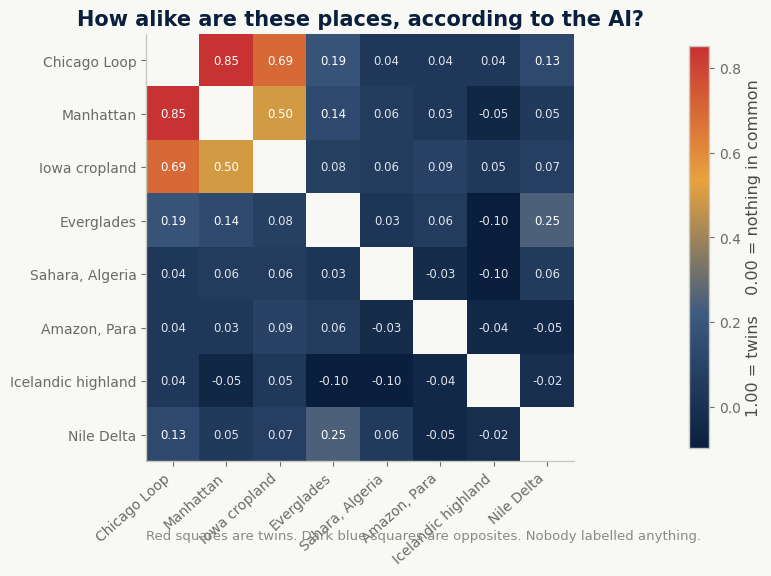


🏆 Most alike:  Chicago Loop  and  Manhattan   (0.85)
🧊 Least alike: Sahara, Algeria  and  Icelandic highland   (-0.10)


In [ ]:
#@title ▶️ Run me: which places are twins? { display-mode: "form" }
PLACES = {
    "Chicago Loop":       (41.8827,  -87.6233),
    "Manhattan":          (40.7580,  -73.9855),
    "Iowa cropland":      (42.0300,  -93.6000),
    "Everglades":         (25.7500,  -80.8000),
    "Sahara, Algeria":    (26.0000,    2.0000),
    "Amazon, Para":       (-3.0000,  -54.0000),
    "Icelandic highland": (64.7000,  -18.5000),
    "Nile Delta":         (30.9000,   31.2000),
}

feats = [ee.Feature(ee.Geometry.Point([lon, lat]).buffer(1500), {"name": n})
         for n, (lat, lon) in PLACES.items()]

sampled = (embedding(YEAR)
           .reduceRegions(collection=ee.FeatureCollection(feats),
                          reducer=ee.Reducer.mean(), scale=100, tileScale=4)
           .select(["name"] + BANDS, retainGeometry=False)
           .getInfo()["features"])

P = pd.DataFrame([f["properties"] for f in sampled]).set_index("name")
P = P.reindex(list(PLACES.keys()))

V = P[BANDS].to_numpy(float)
V = V / np.linalg.norm(V, axis=1, keepdims=True)   # put every arrow back to length 1
S = V @ V.T                                        # every angle, all at once
np.fill_diagonal(S, np.nan)                        # ignore "place vs itself"

fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(S, cmap=HEAT, vmin=np.nanmin(S), vmax=np.nanmax(S))
ax.set_xticks(range(len(P)), P.index, rotation=42, ha="right")
ax.set_yticks(range(len(P)), P.index)
ax.set_title("How alike are these places, according to the AI?")
for i in range(len(P)):
    for j in range(len(P)):
        if i != j:
            ax.text(j, i, f"{S[i,j]:.2f}", ha="center", va="center", fontsize=8.5,
                    color="white" if S[i, j] > np.nanmean(S) else "#dfe4ec")
fig.colorbar(im, ax=ax, shrink=0.72, label="1.00 = twins    0.00 = nothing in common")
caption(ax, "Red squares are twins. Dark blue squares are opposites. Nobody labelled anything.")
plt.show()

hi = np.unravel_index(np.nanargmax(S), S.shape)
lo = np.unravel_index(np.nanargmin(S), S.shape)
print(f"\n🏆 Most alike:  {P.index[hi[0]]}  and  {P.index[hi[1]]}   ({np.nanmax(S):.2f})")
print(f"🧊 Least alike: {P.index[lo[0]]}  and  {P.index[lo[1]]}   ({np.nanmin(S):.2f})")

### 👀 What to look for
Did you guess the winner? Most people guess the two cities and most people are right.

The interesting square is not the obvious one. Look for the pair that surprises you, then think about **why** those two places might genuinely share something: seasonality, water, flatness, how much they change month to month.

### 🎮 Play with it
Add your hometown to `PLACES`. Format is `"Name": (latitude, longitude)`. Right-click any spot in Google Maps to copy its coordinates.

Then ask the real question: **which famous place is your hometown's twin?**

### 💡 What you just learned
You just built a search engine for places, with zero training and about ten lines.

This is what fingerprints are for. Once things are described as numbers in the same space, "find me more like this" becomes arithmetic.

---
# Step 4 · 🔦 Click one spot, light up everywhere like it
### ⏱ 4 minutes

**What you are doing:** the same trick as Step 3, but instead of eight places, we compare your point against **every single pixel** in the region.

Everything similar glows amber and red. Everything different stays dark navy.

**Why this is genuinely useful:** this is how "find all the solar farms" or "find every place that looks like this one good site" gets done now. No training data. No examples. One click.

In [ ]:
#@title ▶️ Run me: pick a spot and light up its matches { display-mode: "form" }
QUERY_LAT = 41.7500   #@param {type:"number"}
QUERY_LON = -87.9000  #@param {type:"number"}

POINT = ee.Geometry.Point([QUERY_LON, QUERY_LAT])
q     = emb.reduceRegion(ee.Reducer.first(), POINT, 10).getInfo()
qvec  = [q[b] for b in BANDS]

# compare the query fingerprint against every pixel at once
sim = (emb.multiply(ee.Image.constant(qvec))
          .reduce(ee.Reducer.sum())
          .rename("sim"))

pcts = sim.reduceRegion(ee.Reducer.percentile([50, 99]), region, 120,
                        maxPixels=1e9).getInfo()
lo, hi = pcts["sim_p50"], pcts["sim_p99"]

m3 = new_map([QUERY_LAT, QUERY_LON], 10)
m3.add_basemap("CartoDB.DarkMatter")
m3.addLayer(sim.clip(region),
            {"min": lo, "max": hi, "palette": ["0A1F3D", "3d5a80", "E8A33D", "C83232"]},
            "similar to your point")
m3.addLayer(POINT, {"color": "white"}, "your point")
m3

Map(center=[41.75, -87.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

### 👀 What to look for
The white dot is your point. Everything red is what the AI considers the same kind of place.

Zoom out. Does the pattern follow something real, like river valleys, suburbs, or field types?

### 🎮 Play with it
Change `QUERY_LAT` and `QUERY_LON` and re-run. Try five wildly different spots: a lake, a runway, a forest, a highway junction, a housing estate.

**Fifteen minutes of doing this teaches you more about what an AI representation knows than reading the research paper.** That is not a joke, it is the single best habit in this notebook.

Now run the chart below to check whether your point was actually interesting.

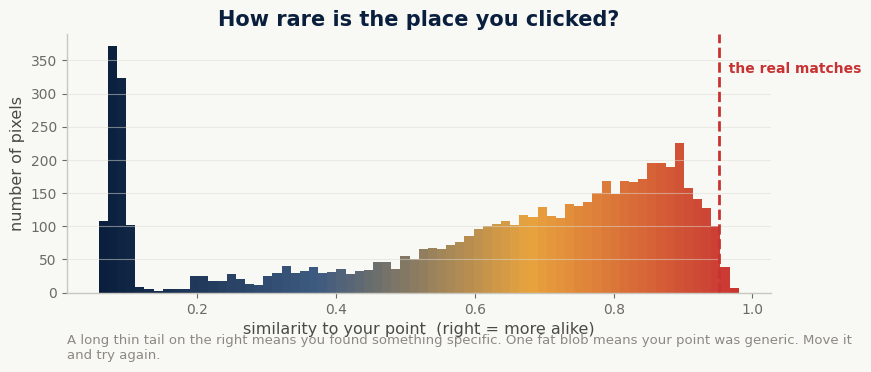

In [ ]:
#@title ▶️ Run me: was your point special or boring? { display-mode: "form" }
vals = np.array((sim.sample(region=region, scale=120, numPixels=6000, seed=3)
                    .aggregate_array("sim").getInfo()), dtype=float)

fig, ax = plt.subplots(figsize=(8.6, 3.6))
n, bins, patches = ax.hist(vals, bins=70, edgecolor="none")
for b, p in zip(bins, patches):
    p.set_facecolor(HEAT((b - vals.min()) / (np.ptp(vals) + 1e-9)))
cut = np.percentile(vals, 99)
ax.axvline(cut, color=CRIMSON, lw=2, ls="--")
ax.text(cut, ax.get_ylim()[1] * 0.85, "  the real matches", color=CRIMSON,
        fontsize=10, fontweight="bold")
ax.set_title("How rare is the place you clicked?")
ax.set_xlabel("similarity to your point  (right = more alike)")
ax.set_ylabel("number of pixels")
ax.grid(axis="y", alpha=0.5)
caption(ax, "A long thin tail on the right means you found something specific. "
            "One fat blob means your point was generic. Move it and try again.")
plt.show()

### 💡 What you just learned
A good search has a **big pile of "nothing like it"** and a **thin tail of real matches**.

If your chart is one fat lump, your query point sat in a boring, average part of the world. That is useful feedback, and it is the same feedback you would want from any search system you build.

---
# Step 5 · 🗺️ Watch the AI sort things it was never taught
### ⏱ 4 minutes

Now we start being scientists instead of tourists.

**What you are doing:**
1. Sampling about a thousand random points
2. Squashing each point's 64 numbers down to 2 so we can draw them on a page
3. Colouring each dot by what it really is (forest, water, city, cropland) using a separate public map

**The crucial bit:** the AI has **never seen those labels**. Not once. If the colours end up in tidy separate clumps anyway, the AI already understood the difference on its own.

We will draw the same picture twice: once with the AI's fingerprints, once with plain old satellite colour bands. The comparison is the point.

In [ ]:
#@title ▶️ Run me: collect samples { display-mode: "form" }
S2B = ["B2", "B3", "B4", "B8", "B11", "B12"]     # plain satellite colour bands
POINTS_PER_TYPE = 130   #@param {type:"integer"}

# the boring baseline: ordinary satellite photo bands
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(f"{YEAR}-01-01", f"{YEAR+1}-01-01")
        .filterBounds(region)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
        .median().select(S2B))

# the answer key: a public land-cover map, made by humans
label = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").rename("label")

sample = (emb.addBands(s2).addBands(label)
             .stratifiedSample(numPoints=POINTS_PER_TYPE, classBand="label",
                               region=region, scale=10, seed=11,
                               geometries=True, tileScale=4))

rows = []
for f in sample.getInfo()["features"]:
    r = dict(f["properties"])
    r["lon"], r["lat"] = f["geometry"]["coordinates"]
    rows.append(r)

df = pd.DataFrame(rows).dropna().reset_index(drop=True)

WC = {10: "Trees", 20: "Shrubs", 30: "Grassland", 40: "Cropland", 50: "City",
      60: "Bare ground", 70: "Snow and ice", 80: "Water", 90: "Wetland",
      95: "Mangrove", 100: "Moss"}
df["type"] = df["label"].map(WC)

# Group nearby points together. Step 6 explains why this line matters so much.
df["block"] = (np.floor(df.lon / 0.12).astype(int).astype(str) + "_" +
               np.floor(df.lat / 0.12).astype(int).astype(str))

print(f"✅ {len(df)} sample points collected, in {df.block.nunique()} neighbourhoods\n")
print(df["type"].value_counts().to_string())

✅ 910 sample points collected, in 63 neighbourhoods

type
Trees          130
Grassland      130
Cropland       130
City           130
Bare ground    130
Water          130
Wetland        130


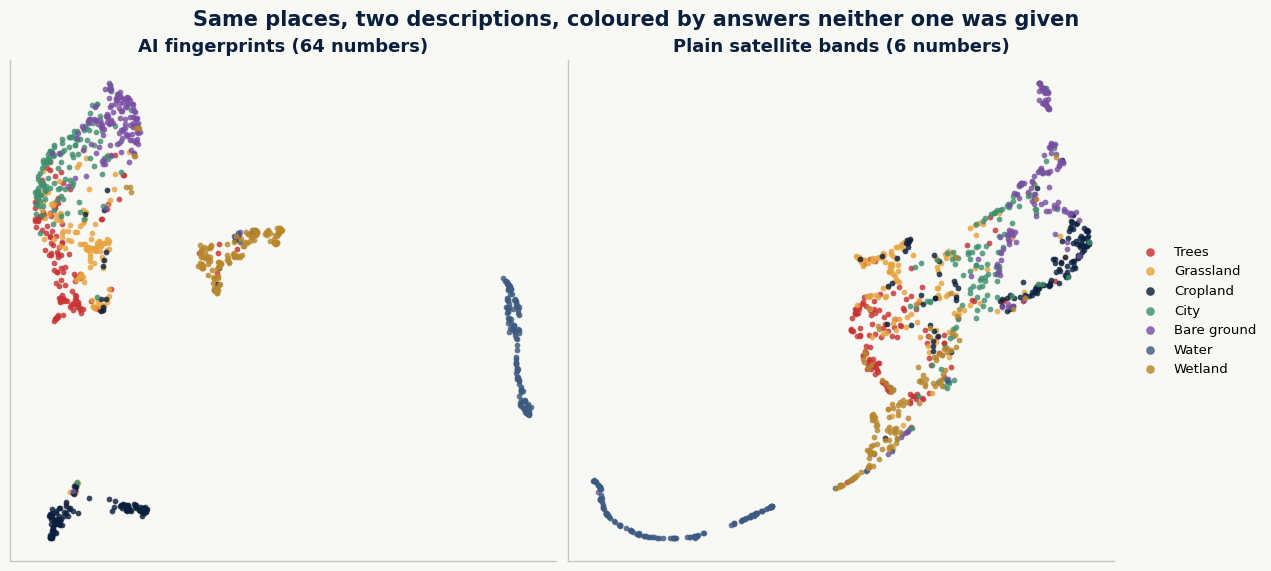

In [ ]:
#@title ▶️ Run me: the picture { display-mode: "form" }
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    import umap
    HAVE_UMAP = True
except Exception:
    HAVE_UMAP = False
    print("(umap not available, using PCA instead. The picture still works.)")

def flatten(X):
    Xs = StandardScaler().fit_transform(X)
    if HAVE_UMAP:
        return umap.UMAP(n_neighbors=18, min_dist=0.12, random_state=0).fit_transform(Xs)
    return PCA(n_components=2, random_state=0).fit_transform(Xs)

types = df["type"].value_counts().index.tolist()
PAL = [CRIMSON, AMBER, NAVY, "#3d8f6f", "#7a4fa3", "#3d5a80", "#b8862b", "#5d5c55", "#c96f9a"]
cmap = {t: PAL[i % len(PAL)] for i, t in enumerate(types)}

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6))
for ax, (cols, name) in zip(axes, [(BANDS, "AI fingerprints (64 numbers)"),
                                   (S2B,   "Plain satellite bands (6 numbers)")]):
    Z = flatten(df[cols].to_numpy(float))
    for t in types:
        mk = df["type"] == t
        ax.scatter(Z[mk, 0], Z[mk, 1], s=17, alpha=0.82, linewidths=0,
                   color=cmap[t], label=t)
    ax.set_title(name, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9.5, markerscale=1.5)
fig.suptitle("Same places, two descriptions, coloured by answers neither one was given",
             fontsize=15, fontweight="bold", color=NAVY)
plt.show()

### 👀 What to look for
**Left panel (AI fingerprints):** colours sit in their own neighbourhoods. Water over here, city over there.

**Right panel (plain satellite bands):** more of a smear. Colours overlap, especially cropland against grassland.

### 🎮 Play with it
Raise `POINTS_PER_TYPE` to 250 and re-run. The clumps get clearer and the contrast between panels gets more obvious.

### 💡 What you just learned
The AI figured out "this is a forest and that is a city" **without ever being told what a forest is**.

That means a model you build on top of it starts most of the way to the answer. Which leads directly to the next step, and the only one that really matters.

---
# Step 6 · 📈 The big one: proving it saves real money
### ⏱ 6 minutes

Everything so far was a nice demo. This step is an **argument you can take into a meeting**.

### The question
Labelling data is the expensive, slow part of nearly every AI project. Somebody sits there tagging examples by hand.

So: **if we use the AI's fingerprints instead of plain satellite bands, how many hand-labelled examples do we save?**

### How we test it fairly
Same model. Same points. Same rules. The *only* thing that changes is the description we feed it.

We start it off starving, with 3 labels per type. Then 5, 8, 13, and so on. We watch how accuracy climbs for both.

### 🚨 The one trick that stops us fooling ourselves
Here is the mistake almost everybody makes.

If you train on one point and test on another point **200 metres away**, that is not a test. It is basically the same place. Your model looks brilliant and it has learned nothing.

So we split by **neighbourhood**: whole areas go into training or testing, never both. It is the honest version, and the number it gives you is always lower and always more real.

> **This applies far beyond maps.** Same person's records in train and test. Same video's frames. Same camera, machine, hospital, or factory. If two rows came from the same source, they cannot sit on both sides of the line.

### 🤔 Guess before you run it
How much better will the AI fingerprints be when labels are scarce? 2%? 10%? 30%?

Write your guess down. Then run it.

In [ ]:
#@title ▶️ Run me: the experiment (takes a couple of minutes) { display-mode: "form" }
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

BUDGETS = [3, 5, 8, 13, 21, 34, 55]     # labels per type
SEEDS   = [0, 1, 2, 3, 4]               # repeat 5 times so it is not a fluke

def honest_accuracy(data, cols, seed):
    clf = RandomForestClassifier(n_estimators=250, random_state=seed, n_jobs=-1)
    return cross_val_score(clf, data[cols].to_numpy(float), data["label"].to_numpy(),
                           cv=GroupKFold(4), groups=data["block"],
                           scoring="accuracy").mean()

available = df["label"].value_counts().min()
BUDGETS   = [b for b in BUDGETS if b <= available]

res = []
for b in BUDGETS:
    for s in SEEDS:
        sub = df.groupby("label", group_keys=False).sample(n=b, random_state=s)
        res.append({"budget": b,
                    "AI fingerprints": honest_accuracy(sub, BANDS, s),
                    "Plain bands":     honest_accuracy(sub, S2B,   s)})
    print(f"   ✓ tested with {b:>3} labels per type")

R = pd.DataFrame(res)
print("\n✅ Done. Run the next cell for the chart.")

   ✓ tested with   3 labels per type
   ✓ tested with   5 labels per type
   ✓ tested with   8 labels per type
   ✓ tested with  13 labels per type
   ✓ tested with  21 labels per type
   ✓ tested with  34 labels per type
   ✓ tested with  55 labels per type

✅ Done. Run the next cell for the chart.


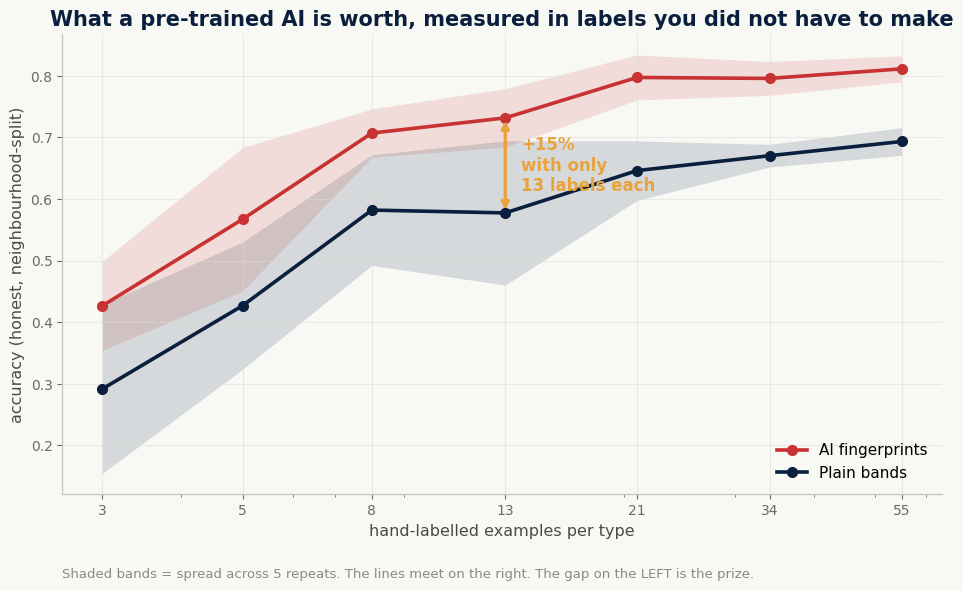

Advantage of AI fingerprints, by label budget:
budget
3     13.5
5     14.0
8     12.5
13    15.4
21    15.1
34    12.5
55    11.8


In [ ]:
#@title ▶️ Run me: THE CHART { display-mode: "form" }
fig, ax = plt.subplots(figsize=(9.4, 5.8))

for name, col in [("AI fingerprints", CRIMSON), ("Plain bands", NAVY)]:
    mu, sd = R.groupby("budget")[name].mean(), R.groupby("budget")[name].std()
    ax.plot(mu.index, mu.values, color=col, lw=2.6, marker="o", ms=7, label=name, zorder=3)
    ax.fill_between(mu.index, mu - sd, mu + sd, color=col, alpha=0.14, lw=0)

gap  = R.groupby("budget")["AI fingerprints"].mean() - R.groupby("budget")["Plain bands"].mean()
best = gap.idxmax()
y0   = R.groupby("budget")["Plain bands"].mean()[best]
y1   = R.groupby("budget")["AI fingerprints"].mean()[best]
ax.annotate("", xy=(best, y1), xytext=(best, y0),
            arrowprops=dict(arrowstyle="<->", color=AMBER, lw=2.4))
ax.text(best * 1.06, (y0 + y1) / 2, f"+{gap.max():.0%}\nwith only\n{best} labels each",
        color=AMBER, fontsize=12, fontweight="bold", va="center")

ax.set_xscale("log"); ax.set_xticks(BUDGETS, [str(b) for b in BUDGETS])
ax.set_xlabel("hand-labelled examples per type")
ax.set_ylabel("accuracy (honest, neighbourhood-split)")
ax.set_title("What a pre-trained AI is worth, measured in labels you did not have to make")
ax.grid(alpha=0.55); ax.legend(loc="lower right", fontsize=11)
caption(ax, "Shaded bands = spread across 5 repeats. The lines meet on the right. "
            "The gap on the LEFT is the prize.")
plt.show()

print("Advantage of AI fingerprints, by label budget:")
print((gap * 100).round(1).to_string())

### 👀 How to read this chart, properly

**Look at the far left, not the peak.**

On the right side the two lines come together. Of course they do. Give any model enough labels and it works things out for itself.

**The gap on the left is the entire prize.** It is the accuracy you get for free, when labels are scarce and expensive, which is the situation on almost every real project.

Read the arrow. If it says +18% at 5 labels each, that translates directly into: *we can start with a fraction of the labelling budget and still ship.*

### 🎮 Play with it
Swap `RandomForestClassifier` for `LogisticRegression` (import it from `sklearn.linear_model`). If the gap survives even a dead-simple model, that proves the **description** is doing the work, not the clever algorithm.

### 💡 What you just learned
You now have a chart that makes an argument nobody can wave away, because it controls for everything except the one thing you changed.

**And you have the honest number**, not the flattering one, because you split by neighbourhood. Try switching to a random split and watch the accuracy jump for no reason at all. That jump is exactly the self-deception this step exists to prevent.

---
# Step 7 · 🕵️ Spot what changed on Earth since 2018
### ⏱ 3 minutes

**What you are doing:** grabbing 2018's fingerprints and 2024's fingerprints for the same places, and measuring how far apart they moved.

Big move means something happened there. New buildings, cleared land, flooding, a new lake.

**There is no change-detection model here.** No training, no threshold tuned on examples. Just two fingerprints and a subtraction. It works because the fingerprints from different years live in the same space by design.

In [ ]:
#@title ▶️ Run me: six years of change { display-mode: "form" }
YEAR_A = 2018  #@param {type:"integer"}
YEAR_B = 2024  #@param {type:"integer"}

A, B_ = embedding(YEAR_A), embedding(YEAR_B)
change = ee.Image.constant(1).subtract(
    A.multiply(B_).reduce(ee.Reducer.sum())).rename("change")

m4 = new_map(CENTER, 10)
m4.add_basemap("CartoDB.DarkMatter")
m4.addLayer(change.clip(region),
            {"min": 0.02, "max": 0.35, "palette": ["0A1F3D", "3d5a80", "E8A33D", "C83232"]},
            f"change {YEAR_A} to {YEAR_B}")
m4

Map(center=[41.8, -87.9], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

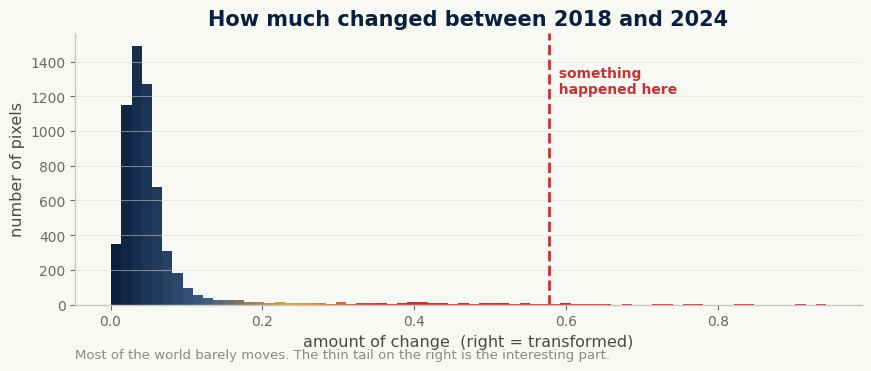

Only 0.5% of sampled places changed dramatically.


In [ ]:
#@title ▶️ Run me: how much of the world actually moved? { display-mode: "form" }
cv = np.array((change.sample(region=region, scale=120, numPixels=6000, seed=5)
                     .aggregate_array("change").getInfo()), dtype=float)

fig, ax = plt.subplots(figsize=(8.6, 3.6))
n, bins, patches = ax.hist(cv, bins=70, edgecolor="none")
for b, p in zip(bins, patches):
    p.set_facecolor(HEAT(min(b / 0.35, 1.0)))
cut = np.percentile(cv, 99.5)
ax.axvline(cut, color=CRIMSON, lw=2, ls="--")
ax.text(cut, ax.get_ylim()[1] * 0.78, "  something\n  happened here",
        color=CRIMSON, fontsize=10, fontweight="bold")
ax.set_title(f"How much changed between {YEAR_A} and {YEAR_B}")
ax.set_xlabel("amount of change  (right = transformed)")
ax.set_ylabel("number of pixels")
ax.grid(axis="y", alpha=0.5)
caption(ax, "Most of the world barely moves. The thin tail on the right is the interesting part.")
plt.show()

print(f"Only {(cv > cut).mean():.1%} of sampled places changed dramatically.")

### 👀 What to look for
On the map, zoom into the red patches. You will usually find a new housing development, a quarry, a solar farm, or a field that switched crops.

### 🎮 Play with it
Change `YEAR_A` and `YEAR_B` at the top of the map cell, then point `region` somewhere that had a big event: a wildfire, a new dam, a city that boomed.

### 💡 What you just learned
Because the fingerprints are comparable across years, "what changed" becomes **subtraction** instead of a project.

That is the quiet superpower of a well-built representation: questions that used to need a whole model become one line of arithmetic.

---
# 🎓 What you now know

You spent 25 minutes and no money, and you can now say all of these truthfully:

✅ **Pre-trained AI descriptions carry real meaning before anyone explains anything.** You painted a map with them and it was legible.

✅ **"Find more like this" is arithmetic once things are described as numbers.** You did it for eight famous places and then for a whole region.

✅ **A model built on a good description starts most of the way home.** You saw the clumps separate for labels the AI never saw.

✅ **That head start is measurable, in labels you did not have to pay for.** You have the chart.

✅ **Testing on the neighbour of your training data is not testing.** You know how to split honestly and why the honest number is lower.

---

## 🚀 The one thing to take to work tomorrow

This was about satellites. It has nothing to do with satellites.

**Three questions, on every project you start, before you write a single line:**

**1. Has somebody already trained a model on this *kind* of data?** Not on your data. On this kind. Text, audio, images, sensor traces, code, molecules, video. Someone probably has.

**2. If the model itself is locked, are its outputs free?** This is the one people miss. Google kept AlphaEarth's model and published everything it produced. That pattern is spreading and almost nobody is looking for it.

**3. How many labels can we honestly afford?** If the answer is "not many", a free pre-trained description plus a simple model will beat your hand-built features. Nearly always. And now you have a chart that proves it.

---

## 🎯 Your challenge

Change **one** line: the `region` box in Step 1. Point it at a place you know personally.

Then run the whole notebook again and see whether your local knowledge agrees with the AI.

That single loop, your intuition against the model's, is worth more than any metric in here.

---

### Liked this?

I write **Standout Systems** daily: AI that actually works, and careers that actually move.
👉 [teodoracoach.substack.com](https://teodoracoach.substack.com/)

I coach ambitious professionals (scientists, engineers, tech people, and not only) who are doing strong work that nobody sees. That is a positioning problem, not a talent problem, and it moves fast.
👉 [teodora.coach](https://teodora.coach/)

**Teodora**

---

*Required credit: the AlphaEarth Foundations Satellite Embedding dataset is produced by Google and Google DeepMind, CC-BY 4.0. Land cover from ESA WorldCover v200. Imagery from Copernicus Sentinel-2.*